# 1c

In [22]:
from __future__ import print_function
import numpy as np

def kmeans(X, k, init=None):
    """ KMEANS implements the k-means algorithm.

    [CLUSTERS, CENTROIDS] = KMEANS(X, K) partitions the data points
    in the N-by-P data matrix X into K distinct clusters, using Euclidean
    distance. This is a simple implementation of the k-means algorithm with
    random initialization.

    Optionally, it takes the argument INIT, a K-by-P matrix with a fixed
    initial position for the cluster centroids.  

    MYKMEANS returns an N-by-1 vector CLUSTERS containing the cluster
    indices of each data point, as well as CENTROIDS, a K-by-P matrix with 
    the final cluster centroids' locations.
    """


    n, p = X.shape

    if init is None:
      #choose initial centroids by picking k points at random from X
      init = X[np.random.randint(n, size=k), :]
    
    #centroids is a k-by-p random matrix
    #its i^th row contains the coordinates of the cluster with index i
    centroids = init

    #initialize cluster assignment array
    clusters = np.zeros(n)

    MAXITER = 1000

    for iter in range(MAXITER):
        
        #create a new clusters vector to fill in with updated assignments
        new_clusters = np.zeros(n)
        

        #for each data point x_i
        for i in range(n):
            
            x_i = X[i,:]
            
            #find closest cluster
            closest = findClosestCluster(x_i,centroids)###IMPLEMENT THIS FUNCTION AT THE END OF THIS FILE

            #reassign x_i to the index of the closest centroid found
            new_clusters[i] = closest

        
        
        if hasConverged(clusters,new_clusters):###IMPLEMENT THIS FUNCTION AT THE END OF THIS FILE
            #exit loop
            break 
        
        
        #otherwise, update assignment
        clusters = new_clusters
        #and recompute centroids
        centroids = recomputeCentroids(X,clusters,k)###IMPLEMENT THIS FUNCTION AT THE END OF THIS FILE

    

    if iter == (MAXITER-1):
        print('Maximum number of iterations reached!')
    
    return clusters, centroids
    

def findClosestCluster(x_i,centroids):
    # Compute Euclidean distance from x_i to each cluster centroid and return 
    # the index of the closest one (an integer).
    # NOTE: use of numpy/scipy.linalg.norm function is NOT allowed here.

    ### Replace the following line with your own code
    closest = min(range(len(centroids)), 
                  key=lambda i:np.sum((x_i - centroids[i])**2)
    )
    return closest



def hasConverged(old_assignment, new_assignment):
    # Check if algorithm has converged, i.e., cluster assignments haven't
    # changed since last iteration. Return a boolean.

    ### Replace the following line with your own code
    map = {}
    converged = True

    return (old_assignment == new_assignment).all()

def recomputeCentroids(X,clusters,k):
    # Recompute centroids based on current cluster assignment.
    # Return a k-by-p array where each row is a centroid. 
    n, p = X.shape
    ### Replace the following line with your own code
    centroids = np.zeros((k,p))
    for i in range(k):
        pts = X[clusters == i]
        if len(pts) > 0:
            centroids[i] = pts.mean(axis=0)
    return centroids
    

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[[0.33422217 0.4054188  0.4819801 ]
 [0.27962326 0.94747089 0.21983674]]


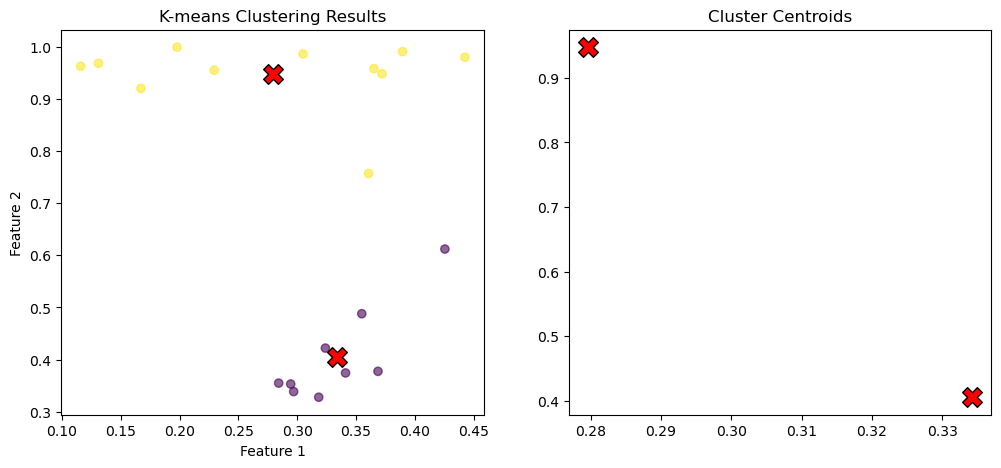

In [ ]:
from scipy.io import loadmat
import matplotlib.pyplot as plt

data = loadmat("tinypics.mat", squeeze_me=True)
x = data["data"]
clusters,centroids = kmeans(x, k=2)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(x[:, 0], x[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, edgecolors='black')
plt.title('K-means Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.subplot(1, 2, 2)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, edgecolors='black')
plt.title('Cluster Centroids')
plt.show()

# 2a

The separation here is pretty clear. Just look at the top half vs the bottom half of the plot. In 5 images, the "Y" in yale is boldened with a photo of a bulldog. In the other 5, the "Y" matches the rest of the letters in Yale.

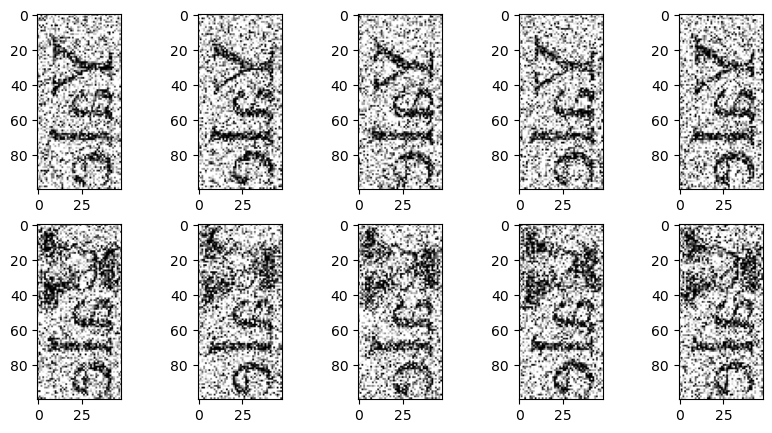

In [ ]:
data = loadmat("logos.mat", squeeze_me=True)
data = data["data"]
images = []
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(0, 10, 1):
    axes[i//5, i%5].imshow(data[:,:,i].T, cmap='gray')